# Demo: 1D Finite Difference Demo for the Wave Equation

This notebook demonstrates a simple explicit finite-difference solution of the 1D scalar wave equation,

$$
\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}.
$$

This version includes **ipywidgets** so you can change parameters live in class.


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive_output, VBox, HBox


## 2. Finite-difference solver

We solve

$$
u_i^{n+1} = 2u_i^n - u_i^{n-1} + C^2\left(u_{i+1}^n - 2u_i^n + u_{i-1}^n\right),
$$

where

$$
C = \frac{c\,dt}{dx}.
$$


In [2]:
def run_fd_1d(c=1.0, L=200.0, dx=1.0, dt=0.8, nt=300,
              x0=80.0, sigma=10.0, boundary='fixed'):
    """
    Solve the 1D wave equation using a centered finite-difference scheme.

    Parameters:
    -----------
    c : float
        Wave speed
    L : float
        Length of the domain
    dx : float
        Spatial grid spacing
    dt : float
        Time step
    nt : int
        Number of time steps
    x0 : float
        Center of initial Gaussian pulse
    sigma : float
        Width of Gaussian pulse
    boundary : str
        Type of boundary condition ('fixed' or 'free')
    """

    # -------------------------
    # Set up spatial grid
    # -------------------------
    nx = int(L / dx) + 1              # number of grid points
    x = np.linspace(0, L, nx)         # spatial coordinates

    # Courant number (controls stability)
    C = c * dt / dx

    # -------------------------
    # Initial condition
    # -------------------------
    # Gaussian pulse centered at x0
    u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

    # u_prev = u at previous time step (n-1)
    # u      = u at current time step (n)
    # We start "at rest", so both are the same initially
    u_prev = u0.copy()
    u = u0.copy()

    # Store solution through time (for plotting/animation)
    snapshots = [u.copy()]

    # -------------------------
    # Time stepping loop
    # -------------------------
    for _ in range(nt):

        # Allocate array for next time step (n+1)
        u_next = np.zeros_like(u)

        # Update interior points using finite difference scheme:
        # u_i^{n+1} = 2u_i^n - u_i^{n-1} + C^2 (u_{i+1}^n - 2u_i^n + u_{i-1}^n)
        u_next[1:-1] = (
            2 * u[1:-1] - u_prev[1:-1]
            + C**2 * (u[2:] - 2 * u[1:-1] + u[:-2])
        )

        # -------------------------
        # Boundary conditions
        # -------------------------
        if boundary == 'fixed':
            # Fixed ends: displacement = 0 (perfect reflection)
            u_next[0] = 0.0
            u_next[-1] = 0.0

        elif boundary == 'free':
            # Free ends: zero spatial derivative (du/dx = 0)
            # Approximate by copying neighboring value
            u_next[0] = u_next[1]
            u_next[-1] = u_next[-2]

        else:
            raise ValueError("boundary must be 'fixed' or 'free'")

        # -------------------------
        # Shift time levels
        # -------------------------
        # Move forward in time:
        # old current -> previous
        # new solution -> current
        u_prev, u = u, u_next

        # Save snapshot
        snapshots.append(u.copy())

    # Return:
    # x          -> spatial coordinates
    # snapshots  -> full time evolution
    # C          -> Courant number (for diagnostics)
    return x, np.array(snapshots), C


## 3. Quick static example

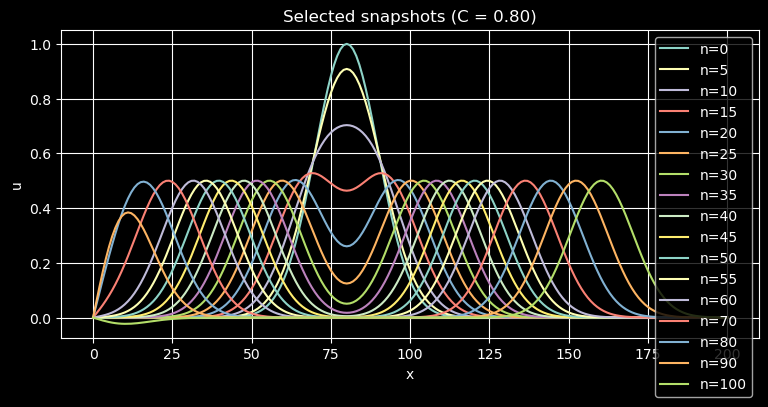

In [3]:
x, snapshots, C = run_fd_1d(c=1.0, L=200.0, dx=1.0, dt=0.8, nt=300,
                            x0=80.0, sigma=10.0, boundary='fixed')

plt.figure(figsize=(9, 4))
for k in [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 80, 90, 100]:
    if k < len(snapshots):
        plt.plot(x, snapshots[k], label=f'n={k}')
plt.xlabel('x')
plt.ylabel('u')
plt.title(f'Selected snapshots (C = {C:.2f})')
plt.grid(True)
plt.legend()
plt.show()


## 4. Interactive widget demo

Use the controls to explore how the solution changes with wave speed, grid spacing, time step, pulse width, and boundary conditions.


In [4]:
def plot_fd_demo(c=1.0, dx=1.0, dt=0.8, nt=200, x0=80.0, sigma=10.0,
                 snapshot=80, boundary='fixed'):
    L = 200.0
    x, snapshots, C = run_fd_1d(c=c, L=L, dx=dx, dt=dt, nt=nt,
                                x0=x0, sigma=sigma, boundary=boundary)

    snapshot = min(snapshot, len(snapshots) - 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, snapshots[0], '--', label='initial')
    ax.plot(x, snapshots[snapshot], label=f'step {snapshot}')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    title = f'1D FD wave equation | C = {C:.2f}'
    if C > 1:
        title += '  (unstable regime)'
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    plt.show()

controls = {
    'c': widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description='c'),
    'dx': widgets.FloatSlider(value=1.0, min=0.5, max=4.0, step=0.5, description='dx'),
    'dt': widgets.FloatSlider(value=0.8, min=0.1, max=2.0, step=0.1, description='dt'),
    'nt': widgets.IntSlider(value=200, min=20, max=400, step=10, description='nt'),
    'x0': widgets.FloatSlider(value=80.0, min=20.0, max=180.0, step=5.0, description='x0'),
    'sigma': widgets.FloatSlider(value=10.0, min=2.0, max=30.0, step=1.0, description='sigma'),
    'snapshot': widgets.IntSlider(value=80, min=0, max=400, step=5, description='step'),
    'boundary': widgets.Dropdown(options=['fixed', 'free'], value='fixed', description='BC')
}

ui_left = VBox([controls['c'], controls['dx'], controls['dt'], controls['nt']])
ui_right = VBox([controls['x0'], controls['sigma'], controls['snapshot'], controls['boundary']])
ui = HBox([ui_left, ui_right])

out = interactive_output(plot_fd_demo, controls)
display(ui, out)


Output()

## 5. A simple animation widget

This uses a frame slider so you can step through the solution during lecture instead of playing a movie.


In [5]:
def make_frame_viewer(c=1.0, dx=1.0, dt=0.8, nt=200, x0=80.0, sigma=10.0, boundary='fixed'):
    x, snapshots, C = run_fd_1d(c=c, L=200.0, dx=dx, dt=dt, nt=nt,
                                x0=x0, sigma=sigma, boundary=boundary)

    def view_frame(frame=0):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(x, snapshots[frame], lw=2)
        ax.set_xlabel('x')
        ax.set_ylabel('u')
        title = f'Frame {frame} | C = {C:.2f}'
        if C > 1:
            title += '  (unstable regime)'
        ax.set_title(title)
        ax.grid(True)
        plt.show()

    interact(view_frame, frame=widgets.IntSlider(value=0, min=0, max=len(snapshots)-1, step=1, description='frame'))

make_frame_viewer(c=1.0, dx=1.0, dt=0.8, nt=200, x0=80.0, sigma=10.0, boundary='fixed')


interactive(children=(IntSlider(value=0, description='frame', max=200), Output()), _dom_classes=('widget-inter…

## 6. List of things to try

1. Increase `dt` until the Courant number gets close to 1.
2. Push `dt` high enough that `C > 1` and show the instability.
3. Change `sigma` to compare broad and narrow pulses.
4. Switch between `fixed` and `free` boundaries.
5. Move the initial pulse by changing `x0`.
